## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.

__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.

### REQUIRED

__Foreach Topic__:
- Problem Statement
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Topic 1 : Airline Passenger Satisfaction

## Problem Statement

Airlines invest heavily in service touchpoints (Wi-Fi, boarding, seat comfort, food, entertainment), but it isn't always clear which of these touchpoints actually move the needle on whether a passenger walks away satisfied or dissatisfied. Without knowing which service factors matter most, airlines risk spending on upgrades that don't meaningfully improve the customer experience.

**Who is impacted:** airline operations/customer-experience teams, and ultimately passengers, who benefit from airlines prioritizing the improvements that matter most.

**Success looks like:** a model that reliably predicts passenger satisfaction from trip/service attributes, paired with a ranked list of the service factors most associated with satisfaction, so the airline can prioritize investment.

## Goals
- Predict whether a passenger will be **satisfied** or **neutral/dissatisfied** based on flight and service attributes.
- Identify which in-flight and pre-flight service factors (Wi-Fi, boarding, seat comfort, entertainment, etc.) are most strongly associated with satisfaction.
- Compare satisfaction patterns across customer type, travel class, and travel purpose.

## Approach
- Frame this as a **binary classification** problem, target = `satisfaction` (satisfied vs. neutral or dissatisfied).
- Clean and encode categorical fields (Gender, Customer_Type, Type_of_Travel, Class).
- Handle the small number of missing `Arrival_Delay_in_Minutes` values (imputation or drop).
- Explore correlations between service-rating features and satisfaction, and check for outliers in delay/distance fields.
- Train baseline classifiers (e.g. Logistic Regression, Random Forest) and evaluate with accuracy/F1/ROC-AUC, since the classes are only mildly imbalanced.

## Data Info
Data Source : [Airline Passenger Satisfaction — Kaggle](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)  
~103,904 rows × 25 columns of survey responses covering passenger demographics, flight details, 14 in-flight/ground service ratings (0-5 scale), delay minutes, and a satisfaction label.

## Data Dictionary
| Column | Type | Description |
| --- | --- | --- |
| id | int | unique passenger identifier |
| Gender | object | Male / Female |
| Customer_Type | object | Loyal Customer / disloyal Customer |
| Age | int | passenger age |
| Type_of_Travel | object | Business travel / Personal Travel |
| Class | object | Eco / Eco Plus / Business |
| Flight_Distance | int | distance of the flight (miles) |
| Inflight_wifi_service ... Cleanliness | int (0-5) | 14 service satisfaction rating columns |
| Departure_Delay_in_Minutes | int | departure delay in minutes |
| Arrival_Delay_in_Minutes | float | arrival delay in minutes (310 missing values) |
| satisfaction | object | **target** — satisfied / neutral or dissatisfied |

In [2]:
df = pd.read_csv('airline_clnd.csv')
df.head()

,SR,id,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [3]:
df.shape

(103904, 25)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   SR                                 103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer_Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type_of_Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight_Distance                    103904 non-null  int64  
 8   Inflight_wifi_service              103904 non-null  int64  
 9   Departure/Arrival_time_convenient  103904 non-null  int64  
 10  Ease_of_Online_booking             103904 non-null  int64  
 11  Gate_location                      103904 non-null

### What is your target column and what does it represent?
The target is **`satisfaction`**, a survey response indicating whether the passenger was overall `satisfied` or `neutral or dissatisfied` with the flight experience.

### Is your target categorical or continuous? Is it balanced?

In [5]:
df['satisfaction'].value_counts(normalize=True)

satisfaction
neutral or dissatisfied    0.566667
satisfied                  0.433333

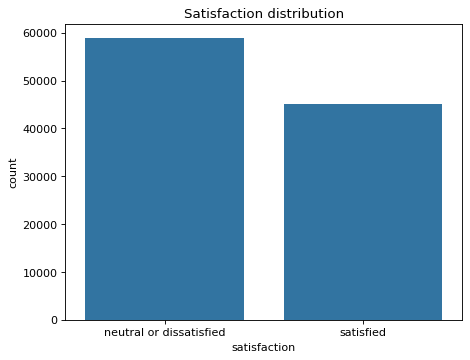

In [6]:
sns.countplot(data=df, x='satisfaction')
plt.title('Satisfaction distribution')
plt.show()

`satisfaction` is **categorical (binary)**. It is roughly balanced: ~56.7% neutral/dissatisfied vs. ~43.3% satisfied — mild imbalance, not severe.

### What types of features do you have (categorical / numerical)? How many of each?

In [7]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}):', cat_cols)
print(f'Numerical columns ({len(num_cols)}):', num_cols)

Categorical columns (5): ['Gender', 'Customer_Type', 'Type_of_Travel', 'Class', 'satisfaction']
Numerical columns (20): ['SR', 'id', 'Age', 'Flight_Distance', 'Inflight_wifi_service', 'Departure/Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On-board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes']


5 categorical columns (Gender, Customer_Type, Type_of_Travel, Class, satisfaction — the target) and 20 numerical columns (14 of which are 0-5 service ratings, plus id, Age, Flight_Distance, and two delay columns).

### How many null values does each feature have? What's your plan for each?

In [8]:
df.isnull().sum()[df.isnull().sum() > 0]

Arrival_Delay_in_Minutes    310

Only `Arrival_Delay_in_Minutes` has missing values (310 rows, ~0.3% of the data). Plan: impute with the median (the column is right-skewed), or drop rows since the volume is negligible.

### Which features are most correlated with your target, and with each other?

In [9]:
target_num = df['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})
corr_with_target = df.select_dtypes(include='number').drop(columns=['id','SR'], errors='ignore').corrwith(target_num).sort_values(ascending=False)
corr_with_target

Online_boarding                      0.503557
Inflight_entertainment               0.398059
Seat_comfort                         0.349459
On-board_service                     0.322383
Leg_room_service                     0.313131
Cleanliness                          0.305198
Flight_Distance                      0.298780
Inflight_wifi_service                0.284245
Baggage_handling                     0.247749
Inflight_service                     0.244741
Checkin_service                      0.236174
Food_and_drink                       0.209936
Ease_of_Online_booking               0.171705
Age                                  0.137167
Gate_location                        0.000682
Departure_Delay_in_Minutes          -0.050494
Departure/Arrival_time_convenient   -0.051601
Arrival_Delay_in_Minutes            -0.057582

`Online_boarding` (~0.50), `Inflight_entertainment` (~0.40), and `Seat_comfort` (~0.35) are the features most positively correlated with satisfaction. Delay-related fields have near-zero/slightly negative correlation with satisfaction on their own.

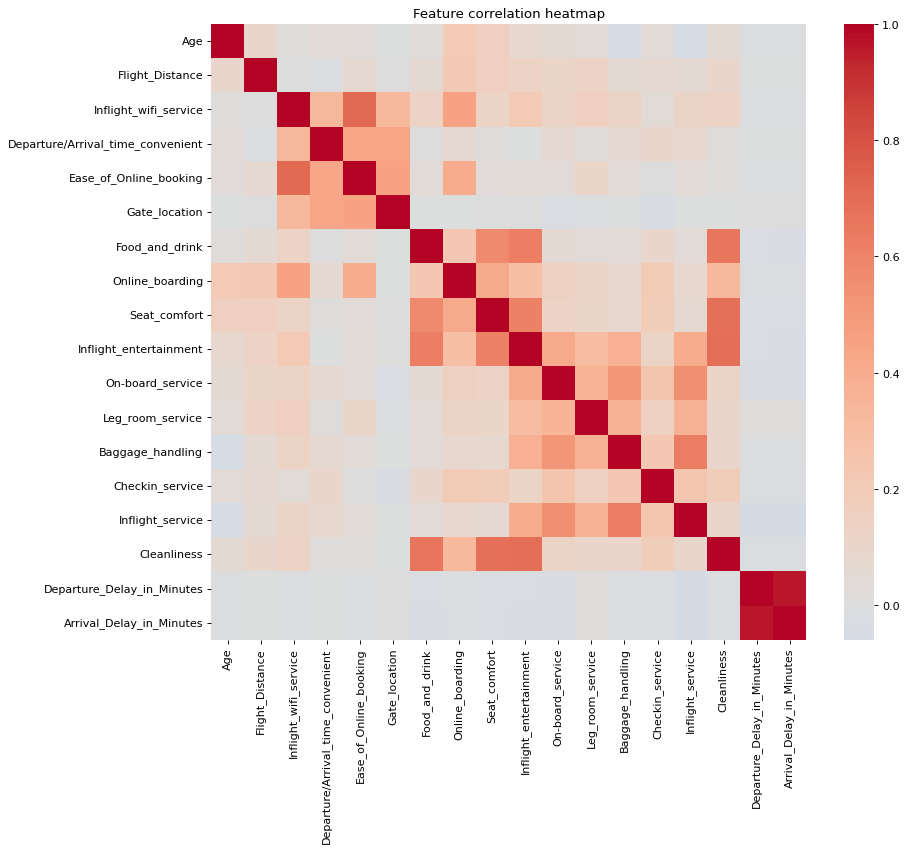

In [10]:
plt.figure(figsize=(12,10))
sns.heatmap(df.select_dtypes(include='number').drop(columns=['id','SR'], errors='ignore').corr(), cmap='coolwarm', center=0)
plt.title('Feature correlation heatmap')
plt.show()

### Are there outliers? How would you handle them?

In [11]:
for c in ['Flight_Distance','Departure_Delay_in_Minutes','Arrival_Delay_in_Minutes']:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = ((df[c] < q1 - 1.5*iqr) | (df[c] > q3 + 1.5*iqr)).sum()
    print(f'{c}: {outliers} outliers ({outliers/len(df)*100:.1f}%)')

Flight_Distance: 2291 outliers (2.2%)
Departure_Delay_in_Minutes: 14529 outliers (14.0%)
Arrival_Delay_in_Minutes: 13954 outliers (13.4%)


Yes — the delay columns have notable outliers (~14% each via IQR), which is expected since most flights have zero/small delays but a few have very large delays. `Flight_Distance` has fewer outliers (~2%). Plan: keep these as real signal (long delays are meaningful, not data errors), but consider capping/log-transforming or using tree-based models that are robust to skew rather than deleting the rows.

## Topic 2 : USDA Nutritional Data Analysis & Health Scoring

### Problem Statement

Navigating food nutritional values is essential for consumers making health-conscious decisions, yet raw nutritional datasets contain complex multi-dimensional metrics (calories, macronutrients, micronutrients, and health scores) across thousands of food items. Without structured insights, identifying optimal food choices, assessing category trends, or predicting health scores based on nutritional profiles becomes exceedingly difficult.

* **Who is impacted:** Health-conscious consumers, dietitians, fitness application users, and public health educators seeking streamlined nutritional insights.
* **Success looks like:** A high-performing regression or classification model that accurately predicts health scores or calorie brackets based on nutritional features, yielding reliable evaluation metrics (such as low RMSE or high ROC-AUC).

### Goals

* Predict target nutritional metrics (such as **Calories** or overall **Health Score**) using macro and micronutrient features.
* Understand which nutritional components (e.g., proteins, fats, sugars, sodium) drive health scores and caloric density.
* Build a robust machine learning pipeline that effectively cleans missing values, handles data skewness, and optimizes model performance.

### Approach

* **Frame as Regression / Classification:** Target = `Health_Score` or `Calories` (Continuous for regression, or categorized bins for classification).
* **Data Cleaning & Preprocessing:** Handle missing nutritional values using median/mean imputation, remove duplicated items, and scale numerical nutrient columns.
* **Feature Engineering & Correlation:** Explore correlations between macronutrients (protein, carbohydrates, total fats) and total calories.
* **Model Training:** Train models such as Linear Regression, Random Forest Regressor, or Gradient Boosting and evaluate using RMSE, MAE, and $R^2$ score.

### Data Info

* **Data Source:** [Global Food & Nutrition Database 2026 — Kaggle](https://www.kaggle.com/datasets/ahsanneural/global-food-and-nutrition-database-2026)
* **Dataset Scale:** ~45,000+ rows $\times$ 10+ columns of comprehensive food items and nutrient metrics.

### Data Dictionary

| Column | Type | Description |
| :--- | :--- | :--- |
| `Food_Item` | string | Name or description of the food item |
| `Category` | string/categorical | Food group or meal category classification |
| `Calories` | float | Total energy content (kcal) |
| `Protein` | float | Protein content in grams |
| `Total_Fat` | float | Total fat content in grams |
| `Carbohydrates` | float | Total carbohydrate content in grams |
| `Sugars` | float | Total sugar content in grams |
| `Fiber` | float | Dietary fiber content in grams |
| `Sodium` | float | Sodium content in milligrams |
| `Health_Score` | float/int | **Target** — overall nutritional health index score |

In [5]:
df2 = pd.read_csv('./comprehensive_foods_usda.csv')
df2.head()

,fdc_id,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_size,serving_unit,household_serving,...,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score,food_type
0,167782,"Abiyuch, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,1.50,0.014,54.1,5.3,1.61,20.0,8.55,NaN,65,Fruits
1,171687,"Acerola juice, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1600.0,0.3,0.50,3.0,4.50,0.0,55,Fruits
2,171686,"Acerola, (west indian cherry), raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1680.0,1.1,0.20,7.0,NaN,0.0,55,Fruits
3,168061,Acorn stew (Apache),SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,6.81,1.280,0.0,0.7,1.00,130.0,0.34,20.0,50,Other
4,168992,"Agave, cooked (Southwest)",SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,0.99,NaN,0.3,10.6,3.55,13.0,20.90,0.0,50,Other


In [6]:
df2.shape

(40000, 24)

In [7]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fdc_id             40000 non-null  int64  
 1   food_name          40000 non-null  str    
 2   data_type          40000 non-null  str    
 3   food_category      39954 non-null  str    
 4   brand_owner        31383 non-null  str    
 5   brand_name         30254 non-null  str    
 6   ingredients        31656 non-null  str    
 7   serving_size       31842 non-null  float64
 8   serving_unit       31842 non-null  str    
 9   household_serving  30790 non-null  str    
 10  calories           39538 non-null  float64
 11  carbs_g            39411 non-null  float64
 12  calcium_mg         34215 non-null  float64
 13  fat_g              39713 non-null  float64
 14  protein_g          39747 non-null  float64
 15  saturated_fat_g    35014 non-null  float64
 16  vitamin_c_mg       22940 non-null

### What is your target column and what does it represent?
The target is `health_score` : it represents the overall nutritional health index score assigned to each food item.

### Is your target categorical or continuous? Is it balanced?

In [8]:
df2['health_score'].value_counts()

health_score
50    13914
40     9815
60     6878
30     3229
55     2984
70     1663
45      827
65      487
35      102
20       51
75       48
25        2
Name: count, dtype: int64

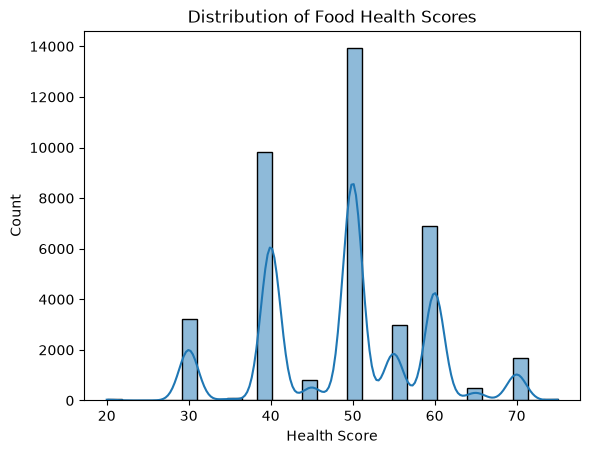

In [9]:
# Plot target distribution
sns.histplot(data=df2, x='health_score', kde=True, bins=30)
plt.title('Distribution of Food Health Scores')
plt.xlabel('Health Score')
plt.ylabel('Count')
plt.show()

`health_score` is **numerical (discrete numeric)** and **imbalanced**: scores are concentrated heavily around values like 30, 40, 50, and 60, with a major peak at 50, while lower and higher extreme scores have very few items. This will drive the modeling approach (e.g., handling skewed regression distributions or binning into ordinal/categorical classes).

### What types of features do you have (categorical / numerical)? How many of each?

In [12]:
cat_cols2 = df2.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
num_cols2 = df2.select_dtypes(include=['number']).columns.tolist()
print(f'Categorical / Object columns ({len(cat_cols2)}):', cat_cols2)
print(f'Numerical columns ({len(num_cols2)}):', num_cols2)

Categorical / Object columns (9): ['food_name', 'data_type', 'food_category', 'brand_owner', 'brand_name', 'ingredients', 'serving_unit', 'household_serving', 'food_type']
Numerical columns (15): ['fdc_id', 'serving_size', 'calories', 'carbs_g', 'calcium_mg', 'fat_g', 'protein_g', 'saturated_fat_g', 'vitamin_c_mg', 'fiber_g', 'iron_mg', 'sodium_mg', 'sugar_g', 'cholesterol_mg', 'health_score']


The dataset contains **9 categorical/object columns** (such as `food_name`, `food_category`, `brand_owner`, and `food_type`) and **15 numerical columns** (including float nutrient metrics like `calories`, `protein_g`, `fat_g`, and the integer target `health_score`).

### How many null values does each feature have? What's your plan for each?

In [13]:
df2.isnull().sum().sum()

np.int64(104446)

Several nutritional columns contain missing values (such as vitamins, minerals, and serving details). Our plan is to handle them using median imputation for skewed numerical nutrient attributes or domain-specific padding where appropriate.

### Which features are most correlated with your target, and with each other?

In [14]:
corr2 = df2.corr(numeric_only=True)['health_score'].sort_values(ascending=False)
print('Most positively correlated with health_score:')
print(corr2.head(6))
print('\nMost negatively correlated with health_score:')
print(corr2.tail(6))

Most positively correlated with health_score:
health_score    1.000000
protein_g       0.288998
fiber_g         0.254939
serving_size    0.194922
iron_mg         0.011606
vitamin_c_mg    0.005817
Name: health_score, dtype: float64

Most negatively correlated with health_score:
carbs_g           -0.104910
calories          -0.125762
fdc_id            -0.143375
fat_g             -0.240956
sugar_g           -0.244268
saturated_fat_g   -0.394539
Name: health_score, dtype: float64


`protein_g`, `fiber_g`, and `serving_size` are the most positively correlated with `health_score`, while `saturated_fat_g`, `sugar_g`, and `fat_g` are the most negatively correlated. Overall, key macronutrients like protein and fiber positively influence the health score, whereas high saturated fats and sugars pull the score down.

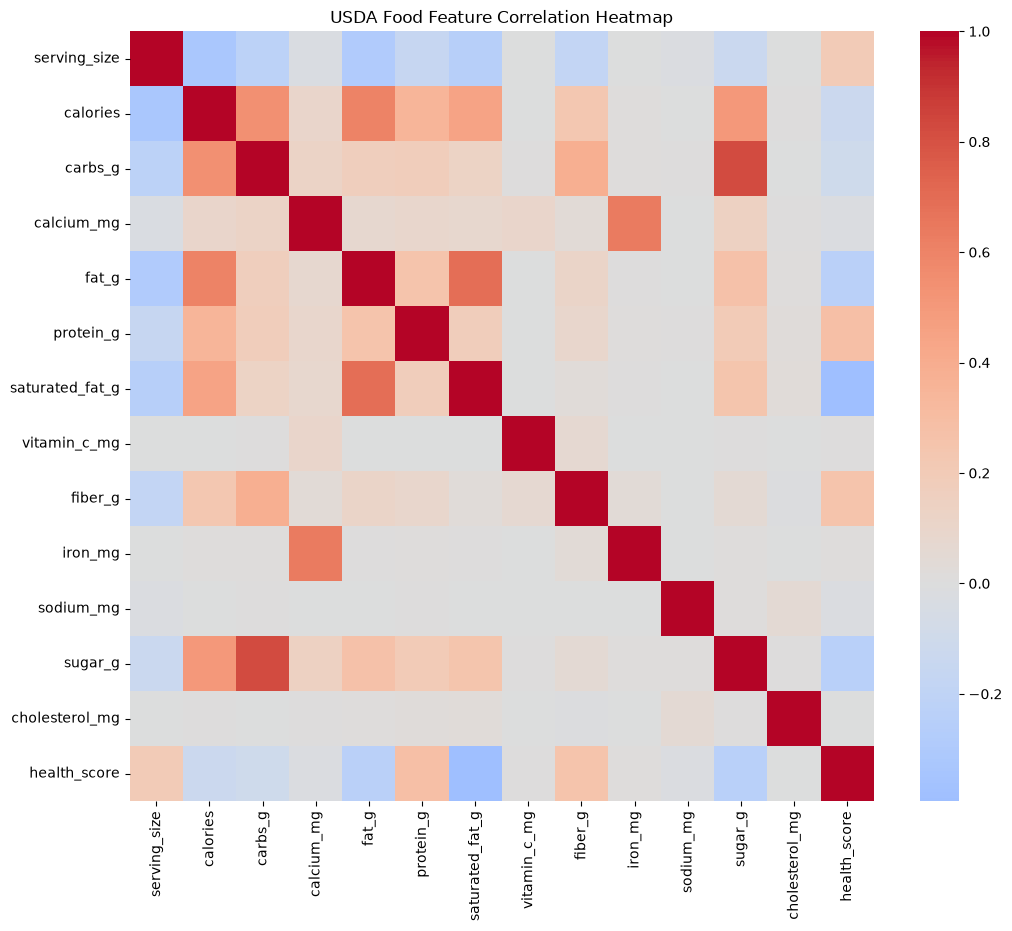

In [15]:
plt.figure(figsize=(12, 10))
sns.heatmap(df2.drop(columns=['fdc_id']).corr(numeric_only=True), annot=False, cmap='coolwarm', center=0)
plt.title('USDA Food Feature Correlation Heatmap')
plt.show()

### Are there outliers? How would you handle them?

In [17]:
q1, q3 = df2['calories'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = ((df2['calories'] < q1 - 1.5*iqr) | (df2['calories'] > q3 + 1.5*iqr)).sum()
print(f'Calories outliers: {outliers} ({outliers/len(df2)*100:.1f}%)')
df2['calories'].describe()

Calories outliers: 1536 (3.8%)


count    39538.000000
mean       308.159861
std        392.575965
min          0.000000
25%         85.000000
50%        250.000000
75%        404.000000
max      37600.000000
Name: calories, dtype: float64

Yes — `calories` and several other macronutrient columns are heavily right-skewed due to extreme items (like dense oils, butters, or large multi-serving meals). Since these extreme values represent real nutritional properties rather than data entry errors, we will not drop them; instead, we can apply log transformations or use robust scaling techniques when training regression models to prevent skewed features from dominating model performance.

# Topic 3 : Network Intrusion Detection (Infiltration Attacks)

## Problem Statement

Network infiltration attacks can slip past traditional signature-based defenses by mimicking normal traffic patterns, and manually inspecting flow-level logs at scale isn't feasible for security teams. Organizations need an automated way to distinguish benign network flows from infiltration attempts using flow-level statistics alone.

**Who is impacted:** network security / SOC teams responsible for detecting intrusions, and, indirectly, the organizations and users whose data is protected.

**Success looks like:** a classifier that separates benign traffic from infiltration traffic using flow features (packet counts, byte counts, timing statistics, flags), with high recall on the attack class so intrusions aren't missed.

## Goals
- Classify network flows as **BENIGN** or **Infiltration**.
- Identify which flow-level statistics (duration, packet size/timing, flag counts) best separate normal from malicious traffic.
- Build a model suitable for near-real-time flagging of suspicious flows.

## Approach
- Frame as **binary classification**, target = `Label` (BENIGN vs. Infiltration).
- Handle missing/infinite values in engineered rate features (e.g. `Flow Bytes/s`) caused by zero-duration flows.
- Drop near-constant / zero-variance columns that add no signal.
- Explore correlation and, given the very high dimensionality (78 features), consider feature selection or dimensionality reduction (e.g. tree-based feature importance, PCA) before modeling.
- Train models such as Random Forest / Gradient Boosting, well-suited to high-dimensional, mixed-scale flow data.

## Data Info
Data Source : [CICIDS2017 Network Intrusion Detection Dataset — Kaggle](https://www.kaggle.com/datasets/cicdataset/cicids2017) (Canadian Institute for Cybersecurity)  
~488,115 rows × 80 columns of network flow statistics generated with CICFlowMeter, labeled as benign or infiltration traffic.

## Data Dictionary
| Column | Type | Description |
| --- | --- | --- |
| Destination Port | int | destination port number of the flow |
| Flow Duration | int | duration of the flow in microseconds |
| Total Fwd/Bwd Packets | int | number of packets sent forward / backward |
| Fwd/Bwd Packet Length Max/Min/Mean/Std | float | packet size statistics per direction |
| Flow Bytes/s, Flow Packets/s | float | throughput rate features |
| Flow/Fwd/Bwd IAT Mean/Std/Max/Min | float | inter-arrival time statistics |
| FIN/SYN/RST/PSH/ACK/URG Flag Count | int | TCP flag counts |
| Active/Idle Mean/Std/Max/Min | float | active vs. idle time statistics for the flow |
| ... | | ~65 additional engineered flow statistics |
| Label | object | **target** — BENIGN / Infiltration |

In [22]:
df3 = pd.read_csv('Network_Traffic.csv', index_col=0)
df3.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,62171,2,2,78,164,39,39,39.00,0.000000,82,82,82.000000,0.000000,3.892490e+03,64.338679,20723.666670,3.589098e+04,62167,1,1,1.000,0.000,1,1,3,3.000,0.000,3,3,0,0,0,0,64,64,32.169339,32.169339,39,82,56.200000,23.552070,554.700000,0,0,0,0,0,0,0,0,1,70.250000,39.00,82.000000,64,0,0,0,0,0,0,2,78,2,164,-1,-1,1,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
1,2710,48,2,0,4,0,2,2,2.00,0.000000,0,0,0.000000,0.000000,8.333333e+04,41666.666670,48.000000,0.000000e+00,48,48,48,48.000,0.000,48,48,0,0.000,0.000,0,0,0,0,0,0,48,0,41666.666670,0.000000,2,2,2.000000,0.000000,0.000000,0,0,0,1,0,0,0,0,0,3.000000,2.00,0.000000,48,0,0,0,0,0,0,2,4,0,0,1024,-1,1,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
2,443,4792909,5,1,135,46,46,6,27.00,20.124612,46,46,46.000000,0.000000,3.776412e+01,1.251849,958581.800000,2.004089e+06,4540768,4,4792909,1198227.250,2230953.215,4540768,4,0,0.000,0.000,0,0,1,0,0,0,100,20,1.043208,0.208642,6,46,32.428571,18.866700,355.952381,0,1,0,0,1,0,0,0,0,37.833333,27.00,46.000000,100,0,0,0,0,0,0,5,135,1,46,255,360,4,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
3,80,115596470,75,82,342,118155,342,0,4.56,39.490758,4344,0,1440.914634,853.758259,1.025092e+03,1.358173,741003.012800,2.593995e+06,10000000,1,116000000,1562114.459,3609826.592,10000000,89,110000000,1361157.432,3452427.698,10000000,49,0,0,0,0,2408,2632,0.648809,0.709364,0,4344,749.981013,946.124811,895152.158900,0,0,0,1,0,0,0,0,1,754.757962,4.56,1440.914634,2408,0,0,0,0,0,0,75,342,82,118155,29200,59,1,32,22092.63636,22835.59127,90944,14999,10000000.0,2701.650839,10000000,9997164,BENIGN
4,2910,14,2,2,4,12,2,2,2.00,0.000000,6,6,6.000000,0.000000,1.142857e+06,285714.285700,4.666667,4.725816e+00,10,1,3,3.000,0.000,3,3,10,10.000,0.000,10,10,0,0,0,0,48,40,142857.142900,142857.142900,2,6,3.600000,2.190890,4.800000,0,0,0,1,0,0,0,0,1,4.500000,2.00,6.000000,48,0,0,0,0,0,0,2,4,2,12,1024,0,1,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN


In [23]:
df3.shape

(488115, 79)

In [24]:
df3.info(verbose=False)

<class 'pandas.DataFrame'>
RangeIndex: 488115 entries, 0 to 488114
Columns: 79 entries, Destination Port to Label
dtypes: float64(24), int64(54), str(1)
memory usage: 294.2 MB


### What is your target column and what does it represent?
The target is **`Label`**: `BENIGN` for normal traffic flows, `Infiltration` for flows identified as intrusion/infiltration attacks.

### Is your target categorical or continuous? Is it balanced?

In [25]:
df3['Label'].value_counts(normalize=True)

Label
BENIGN          0.591184
Infiltration    0.408816

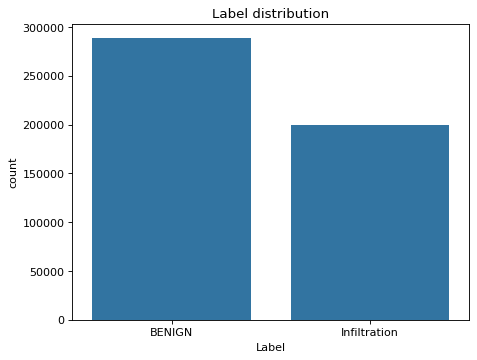

In [26]:
sns.countplot(data=df3, x='Label')
plt.title('Label distribution')
plt.show()

`Label` is **categorical (binary)**. It's reasonably balanced for this subset — ~59% BENIGN vs. ~41% Infiltration — much less imbalanced than a typical raw intrusion-detection dataset, which is favorable for modeling.

### What types of features do you have (categorical / numerical)? How many of each?

In [27]:
cat_cols3 = df3.select_dtypes(include='object').columns.tolist()
num_cols3 = df3.select_dtypes(include='number').columns.tolist()
print(f'Categorical columns ({len(cat_cols3)}):', cat_cols3)
print(f'Numerical columns ({len(num_cols3)}):', len(num_cols3))

Categorical columns (1): ['Label']
Numerical columns (78): 78


Only **1 categorical column** (`Label`, the target) and **78 numerical columns** — this is an almost entirely numeric, high-dimensional flow-statistics dataset.

### How many null values does each feature have? What's your plan for each?

In [28]:
df3.isnull().sum()[df3.isnull().sum() > 0]

Flow Bytes/s    36

Only `Flow Bytes/s` has missing values (36 rows), which occur when `Flow Duration` is 0 (undefined rate). Plan: impute with 0 or the median, or drop the handful of affected rows since the volume is negligible relative to the dataset size.

### Which features are most correlated with your target, and with each other?

In [29]:
target3 = df3['Label'].map({'BENIGN': 0, 'Infiltration': 1})
num3 = df3.select_dtypes(include='number').replace([np.inf, -np.inf], np.nan)
num3 = num3.loc[:, num3.nunique() > 1]  # drop constant columns
num3 = num3.fillna(num3.median())
corr3 = num3.corrwith(target3).abs().sort_values(ascending=False)
corr3.head(10)

act_data_pkt_fwd               0.002475
FIN Flag Count                 0.002147
min_seg_size_forward           0.001999
Active Min                     0.001998
Flow IAT Min                   0.001973
Active Mean                    0.001845
Subflow Fwd Bytes              0.001709
Total Length of Fwd Packets    0.001706
Destination Port               0.001600
Init_Win_bytes_forward         0.001580

Interestingly, **no single feature is strongly linearly correlated with `Label`** — the top correlations are all below 0.01. This suggests infiltration traffic isn't separable along any one flow statistic individually; the signal is likely spread across combinations of features, which points toward tree-based / ensemble models (which capture interactions and non-linear splits) rather than linear models.

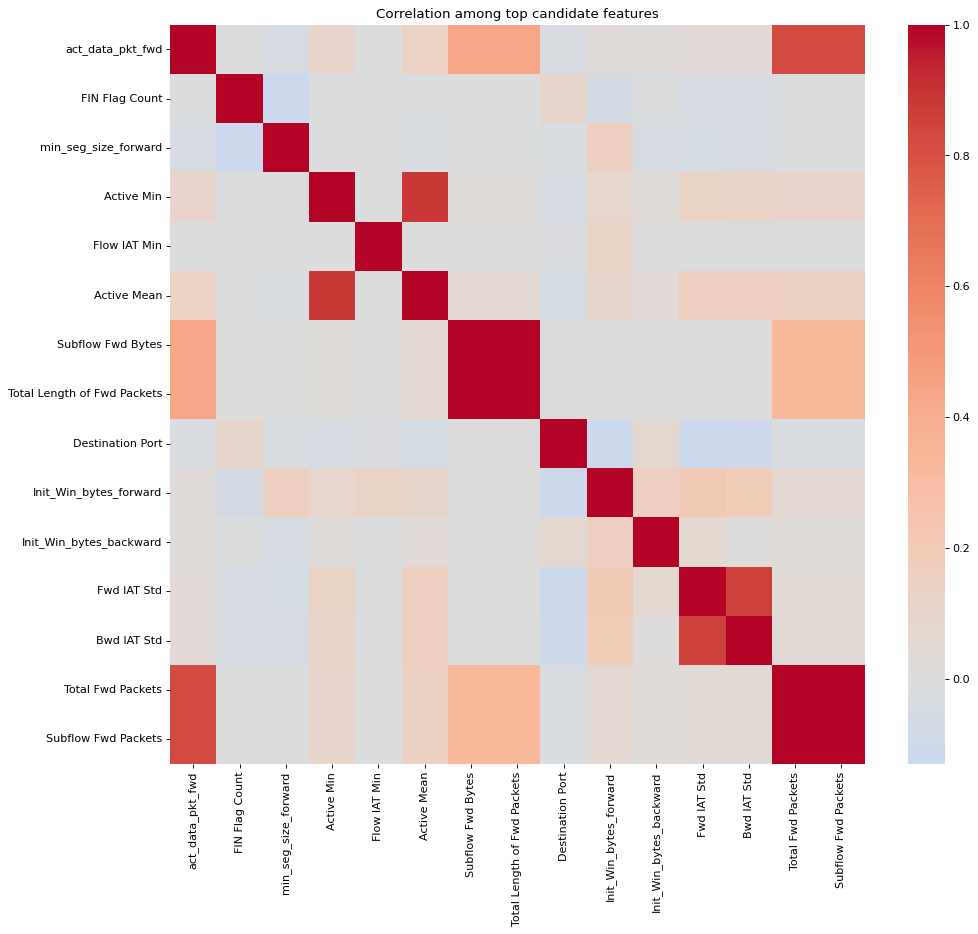

In [30]:
plt.figure(figsize=(14,12))
top_feats = corr3.head(15).index.tolist()
sns.heatmap(num3[top_feats].corr(), cmap='coolwarm', center=0)
plt.title('Correlation among top candidate features')
plt.show()

### Are there outliers? How would you handle them?

In [31]:
q1, q3 = df3['Flow Duration'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = ((df3['Flow Duration'] < q1 - 1.5*iqr) | (df3['Flow Duration'] > q3 + 1.5*iqr)).sum()
print(f'Flow Duration outliers: {outliers} ({outliers/len(df3)*100:.1f}%)')
df3['Flow Duration'].describe()

Flow Duration outliers: 100879 (20.7%)


count    4.881150e+05
mean     8.942263e+06
std      2.748091e+07
min     -2.000000e+00
25%      5.900000e+01
50%      3.100000e+02
75%      1.002090e+05
max      1.199999e+08

Yes — `Flow Duration` has a substantial number of outliers (~21% by IQR), reflecting a mix of very short probe-like connections and long-lived sessions. Since unusually short/long flows can be a meaningful attack signature rather than noise, we'd avoid deleting them outright and instead use robust scaling (e.g. RobustScaler, log-transform) or rely on tree-based models that are naturally robust to skew and outliers.